<a href="https://colab.research.google.com/github/Sharmaluvkesh/Book-recommendation-system/blob/main/Book_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interactive Book Recommendation & Exploratory Data Analysis
This notebook contains a complete data analysis pipeline featuring multiple data visualizations and an interactive Content-Based Filtering Book Recommendation Model.

### **Step 1: Import the dependencies**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

### **Step 2: Load the dataset and handle missing values**

In [2]:
df = pd.read_csv('data.csv')

print('--- First 5 Rows ---')
print(df.head())
print('\n--- Data Shape ---')
print(df.shape)

# Handle missing text data for recommendation engine
df['title'] = df['title'].fillna('Unknown Title')
df['description'] = df['description'].fillna('')
df['categories'] = df['categories'].fillna('Uncategorized')
df['authors'] = df['authors'].fillna('Unknown Author')

# Clean numeric features
df['average_rating'] = pd.to_numeric(df['average_rating'], errors='coerce').fillna(df['average_rating'].median())
df['num_pages'] = pd.to_numeric(df['num_pages'], errors='coerce').fillna(df['num_pages'].median())
df['ratings_count'] = pd.to_numeric(df['ratings_count'], errors='coerce').fillna(0)

--- First 5 Rows ---
          isbn13      isbn10           title subtitle  \
0  9780002005883  0002005883          Gilead      NaN   
1  9780002261982  0002261987    Spider's Web  A Novel   
2  9780006163831  0006163831    The One Tree      NaN   
3  9780006178736  0006178731  Rage of angels      NaN   
4  9780006280897  0006280897  The Four Loves      NaN   

                           authors                     categories  \
0               Marilynne Robinson                        Fiction   
1  Charles Osborne;Agatha Christie  Detective and mystery stories   
2             Stephen R. Donaldson               American fiction   
3                   Sidney Sheldon                        Fiction   
4              Clive Staples Lewis                 Christian life   

                                           thumbnail  \
0  http://books.google.com/books/content?id=KQZCP...   
1  http://books.google.com/books/content?id=gA5GP...   
2  http://books.google.com/books/content?id=OmQaw... 

### **Step 3: Visual Analysis - Bar Chart (Top 10 Book Categories)**

/tmp/ipykernel_1291/4107001193.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')


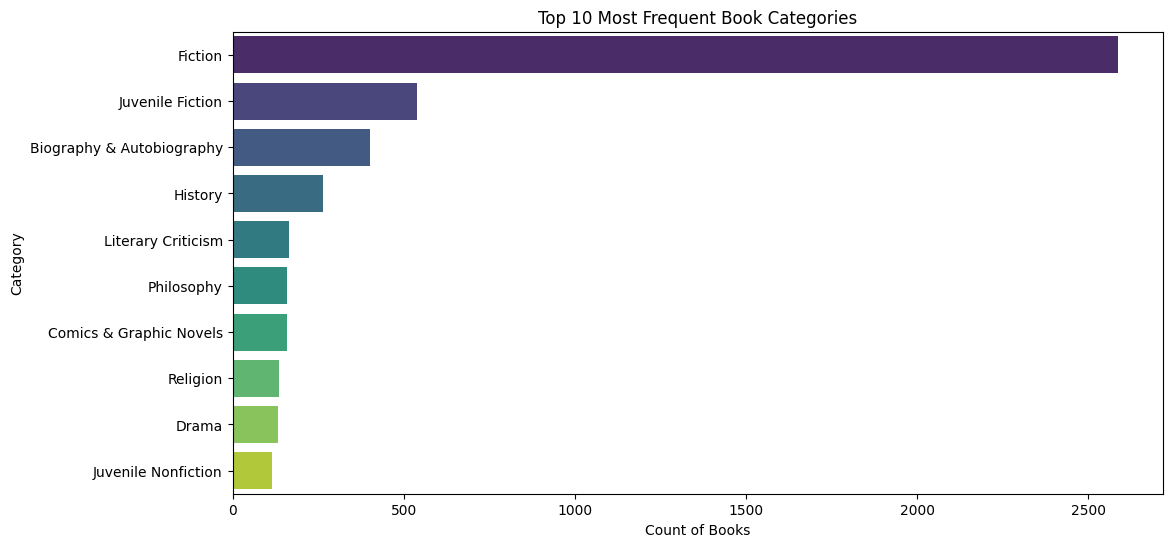

In [3]:
plt.figure(figsize=(12, 6))
top_categories = df['categories'].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.title('Top 10 Most Frequent Book Categories')
plt.xlabel('Count of Books')
plt.ylabel('Category')
plt.show()

### **Step 4: Visual Analysis - Pie Chart (Distribution of Top 5 Authors)**

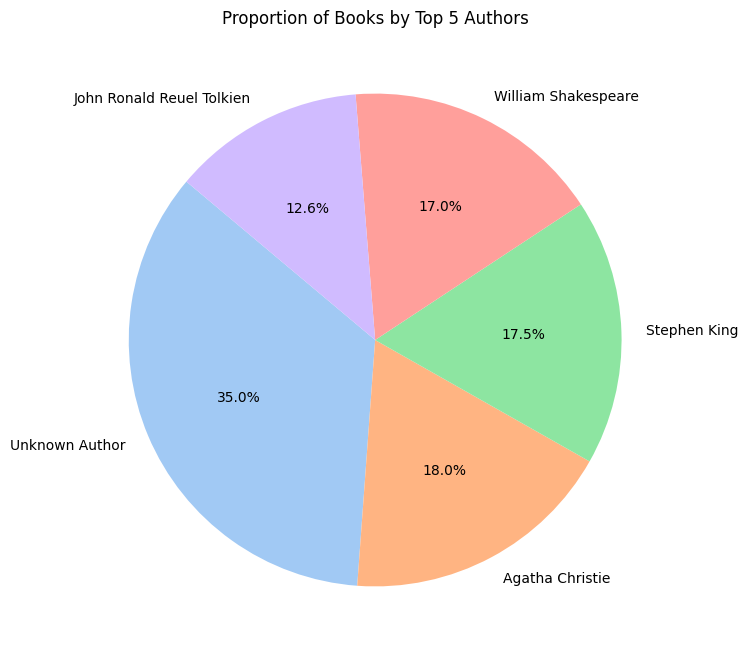

In [4]:
plt.figure(figsize=(8, 8))
top_authors = df['authors'].value_counts().head(5)
plt.pie(top_authors.values, labels=top_authors.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proportion of Books by Top 5 Authors')
plt.show()

### **Step 5: Visual Analysis - Dot / Scatter Plot (Relationship Between Page Count and Average Rating)**

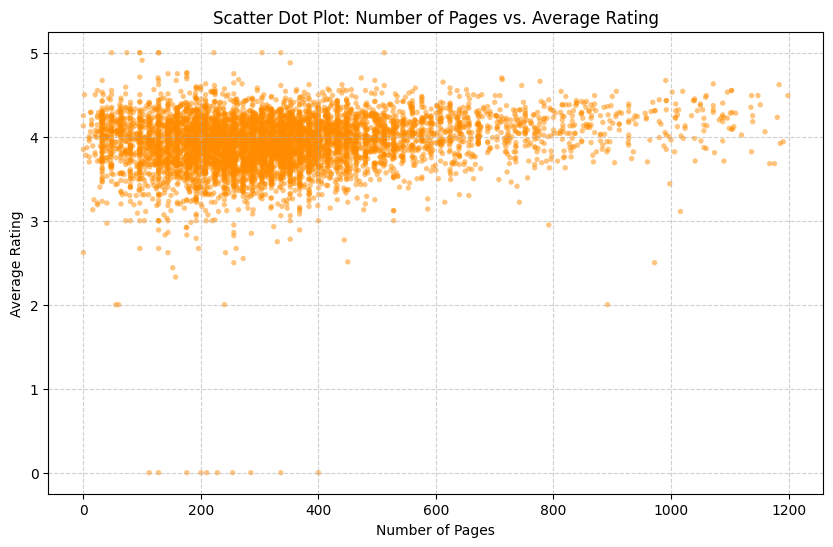

In [5]:
plt.figure(figsize=(10, 6))
filtered_df = df[df['num_pages'] < 1200]
plt.scatter(filtered_df['num_pages'], filtered_df['average_rating'], alpha=0.5, color='darkorange', edgecolors='none', s=15)
plt.title('Scatter Dot Plot: Number of Pages vs. Average Rating')
plt.xlabel('Number of Pages')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### **Step 6: Visual Analysis - Boxplot (Spread of Average Ratings)**

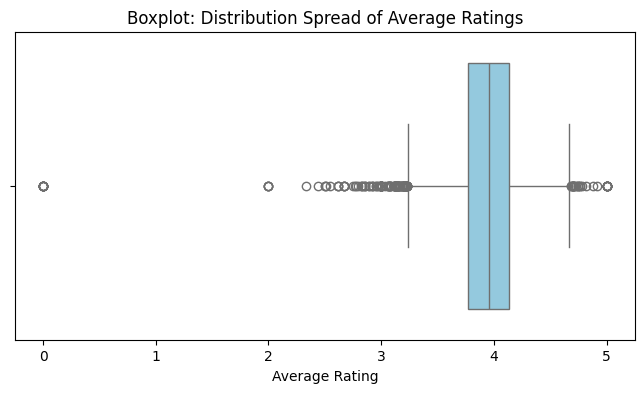

In [6]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['average_rating'], color='skyblue')
plt.title('Boxplot: Distribution Spread of Average Ratings')
plt.xlabel('Average Rating')
plt.show()

### **Step 7: Build Content-Based Recommendation System Feature Matrix**

In [7]:
df['combined_features'] = df['description'] + " " + df['categories']

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['combined_features'])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Recommendation baseline matrix calculated successfully!")

Recommendation baseline matrix calculated successfully!


### **Step 8: Define Recommendation Core Function**

In [8]:
def get_book_recommendations(title, cosine_similarity_matrix=cosine_sim, data=df, num_recommendations=5):
    data['title_lower'] = data['title'].str.lower()
    title_clean = title.strip().lower()

    if title_clean not in data['title_lower'].values:
        return None

    idx = data[data['title_lower'] == title_clean].index[0]
    sim_scores = list(enumerate(cosine_similarity_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:num_recommendations+1]
    book_indices = [i[0] for i in sim_scores]

    return data[['title', 'authors', 'categories', 'average_rating']].iloc[book_indices]

### **Step 9: Interactive Book Recommendation Search**
Run this cell, type a title from the dataset into the prompt box, and hit Enter.

In [9]:
user_input = input("Enter a book title to get recommendations: ")
results = get_book_recommendations(user_input, num_recommendations=5)

if results is None:
    print(f"\n[Error] Book titled '{user_input}' was not found in the dataset.")
    print("Please check the spelling or try another title from your data file.")
else:
    print(f"\nTop 5 book recommendations for '{user_input}':")
    display(results)

Enter a book title to get recommendations: the one tree

Top 5 book recommendations for 'the one tree':


,title,authors,categories,average_rating
5619,The Eye of the I,David R. Hawkins,"Body, Mind & Spirit",4.38
3750,Understanding the Lord of the Rings,Neil D. Isaacs;Rose A. Zimbardo,Literary Criticism,4.02
2465,"Three Famous Short Novels: short novels, Spott...",William Faulkner,American fiction,3.86
3646,Mistress of the Empire,Raymond E. Feist;Janny Wurts,English fiction,4.31
5195,Legends,George R. R. Martin;Anne McCaffrey,Fiction,3.88
